In [24]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
import torch
import torch.nn as nn
import matplotlib.patches as patches

from torch.utils.data import Dataset, DataLoader

device = "cuda"
torch.backends.cudnn.benchmark = True

In [25]:
# -----------------------
# 1. Generate wave equation data (Dirichlet BC)
# -----------------------
def wave_solver_dirichlet(u0, ut0, c=1.0, dx=1/128, dt=1e-4, n_steps=2000):
    """Explicit finite-difference solver for 1D wave equation (Dirichlet BCs u(0,t)=u(1,t)=0)."""
    Nx = len(u0)
    u = u0.copy()
    u_prev = u0.copy()  # u at previous time step
    
    # Initialize first time step using initial velocity
    u_new = u.copy()
    for i in range(1, Nx - 1):
        lap = (u[i+1] - 2*u[i] + u[i-1]) / dx**2
        u_new[i] = u[i] + dt * ut0[i] + 0.5 * c**2 * dt**2 * lap
    u_prev = u.copy()
    u = u_new.copy()
    
    traj = [u0.copy(), u.copy()]
    
    for _ in range(n_steps - 1):
        u_new = u.copy()
        
        # discrete Laplacian on interior points only
        for i in range(1, Nx - 1):
            lap = (u[i+1] - 2*u[i] + u[i-1]) / dx**2
            u_new[i] = 2*u[i] - u_prev[i] + c**2 * dt**2 * lap
        
        # Dirichlet boundaries
        u_new[0] = 0.0
        u_new[-1] = 0.0
        
        u_prev = u.copy()
        u = u_new.copy()
        traj.append(u.copy())
    
    return np.stack(traj)  # shape (T, Nx)

def generate_wave_data(Nx=128, c=1.0, dt=1e-4, n_steps=4000):
    dx = 1.0 / (Nx - 1)
    x = np.linspace(0, 1, Nx)

    # initial condition compatible with Dirichlet BC
    u0 = np.sin(2*np.pi * x)   # = 0 at x=0 and x=1
    ut0 = np.zeros_like(x)   # zero initial velocity (nice and simple)

    data = wave_solver_dirichlet(u0, ut0, c, dx, dt, n_steps)
    return x, data  # data[t, x]

# -----------------------
# 3. Training setup
# -----------------------
Nx = 500
dt0 = 1e-4
c = 1.0
n_steps = 9000

x, data = generate_wave_data(Nx, c, dt0, n_steps)

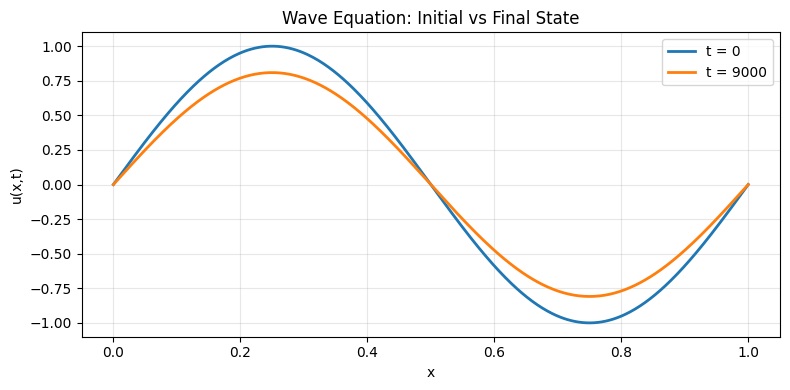

In [26]:
t_plot = n_steps//1 # or whatever final index you used

plt.figure(figsize=(8,4))
plt.plot(x, data[0], label="t = 0", linewidth=2)
plt.plot(x, data[t_plot], label=f"t = {t_plot}", linewidth=2)
plt.title("Wave Equation: Initial vs Final State")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
def sample_one_B(u, R=5, k=5, max_tries=50, u_scale=None, rng=np.random):
    """
    Sample a single Scheme-B training example using an index-space square.

    Square geometry:
        t in [t0-R, t0+R], x in [x0-R, x0+R]

    Returns:
        feats_flat: (k*3,) with [dt_scaled, dx_scaled, u_scaled]
        target: scalar normalized u(t0,x0)
    """
    Nt, Nx = u.shape

    if u_scale is None:
        u_scale = np.max(np.abs(u)) + 1e-8

    for _ in range(max_tries):

        # ---- 1. sample random center ----
        t0 =  rng.randint(0, Nt)
        x0 =  rng.randint(0, Nx)

        # ---- 2. square bounds ----
        t_min = max(0, t0 - R)
        t_max = min(Nt - 1, t0 + R)
        x_min = max(0, x0 - R)
        x_max = min(Nx - 1, x0 + R)

        # ---- 3. collect candidates ----
        cand = []
        for t in range(t_min, t_max + 1):
            for x in range(x_min, x_max + 1):
                if t == t0 and x == x0:
                    continue
                cand.append((t, x))

        if len(cand) < k:
            continue

        # ---- 4. pick k random neighbors ----
        cand = np.array(cand)
        idx = np.random.choice(len(cand), size=k, replace=False)
        neigh = cand[idx]

        # ---- 5. build feature vector ----
        feats = []
        for (tn, xn) in neigh:
            dt_scaled = (t0 - tn)
            dx_scaled = (x0 - xn)
            u_scaled = u[tn, xn] / u_scale
            feats.append([dt_scaled, dx_scaled, u_scaled])

        feats = np.array(feats, dtype=np.float32).reshape(-1)
        target = np.float32(u[t0, x0] / u_scale)
        return feats, target

    raise RuntimeError("Failed to sample B-example; try changing R/k.")

In [28]:
class BDataset(Dataset):
    """
    Scheme-B dataset:
    - u: PDE solution, shape (Nt, Nx)
    - N_samples: number of samples
    """
    def __init__(self, u, N_samples=50000, R=5, k=5, seed=0, pregenerate=False):
        self.u = u
        self.N_samples = N_samples
        self.R = R
        self.k = k
        self.rng = np.random.RandomState(seed)

        # global normalization for u
        self.u_scale = np.max(np.abs(u)) + 1e-8

        self.pregenerate = pregenerate
        if pregenerate:
            print(f"Pre-generating {N_samples} samples...")
            feats = []
            targets = []

            for i in range(N_samples):
                if (i + 1) % 10000 == 0:
                    print(f"  Generated {i+1}/{N_samples}")

                f, t = sample_one_B(
                    self.u,
                    R=self.R,
                    k=self.k,
                    u_scale=self.u_scale,
                    rng=self.rng,
                )
                feats.append(f)
                targets.append(t)

            self.feats_tensor = torch.from_numpy(
                np.asarray(feats, dtype=np.float32)
            )
            self.targets_tensor = torch.from_numpy(
                np.asarray(targets, dtype=np.float32)
            )

            print("Pre-generation complete.")

    def __len__(self):
        return self.N_samples

    def __getitem__(self, idx):
        if self.pregenerate:
            return self.feats_tensor[idx], self.targets_tensor[idx]
        else:
            feats, target = sample_one_B(
                self.u,
                R=self.R,
                k=self.k,
                u_scale=self.u_scale,
                rng=self.rng,
            )
            return (
                torch.from_numpy(feats),
                torch.tensor(target, dtype=torch.float32),
            )

In [29]:
class LinearIntegrator(nn.Module):
    def __init__(self, k=5):
        super().__init__()
        self.lin = nn.Linear(k * 3, 1)

    def forward(self, x):
        return self.lin(x).squeeze(-1)

In [30]:
class MLPIntegrator(nn.Module):
    def __init__(self, k=5, hidden=128, num_layers=3):
        super().__init__()
        in_dim = k * 3
        layers = [nn.Linear(in_dim, hidden), nn.ReLU()]

        for _ in range(num_layers - 2):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]

        layers.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

In [31]:
def train_integrator_B(
    model,
    u,
    epochs=50,
    batch_size=2048,
    k=5,
    R=5,
    N_samples=100000,
    lr=1e-3,
    pregenerate=True,
):
    """
    Minimal training loop for Scheme-B integrators.

    Args:
        model: torch.nn.Module (linear or MLP)
        u: numpy array (Nt, Nx)
    Returns:
        model: trained model
        train_losses: list of epoch-wise MSE
    """
    device = "cuda"
    model = model.to(device)

    dataset = BDataset(
        u,
        N_samples=N_samples,
        R=R,
        k=k,
        pregenerate=pregenerate,
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True,
    )

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for feats, target in loader:
            feats = feats.to(device)
            target = target.to(device)

            opt.zero_grad()
            pred = model(feats)
            loss = loss_fn(pred, target)
            loss.backward()
            opt.step()

            total_loss += loss.item() * feats.size(0)

        avg_loss = total_loss / len(dataset)
        train_losses.append(avg_loss)

        print(f"[Epoch {epoch+1}/{epochs}] train MSE = {avg_loss:.6e}")

    return model, train_losses

In [32]:
def eval_integrator_B(model, u, R, k, N_test=10000, batch_size=4096,):
    device = "cuda"
    model.eval()
    test_ds = BDataset( u, N_samples=N_test,R=R,k=k, seed=123,pregenerate=True,    )
    loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0,pin_memory=True,)
    loss_fn = nn.MSELoss()
    total_loss = 0.0
    with torch.no_grad():
        for feats, target in loader:
            feats = feats.to(device)
            target = target.to(device)
            pred = model(feats)
            loss = loss_fn(pred, target)
            total_loss += loss.item() * feats.size(0)
    avg_loss = total_loss / N_test
    print(f"[Eval] MSE = {avg_loss:.6e}")
    return avg_loss

In [33]:
def visualize_B_compare_models(u, model_lin, model_mlp, R=5, k=5):
    device = "cuda"
    model_lin.eval()
    model_mlp.eval()

    Nt, Nx = u.shape

    # ---- choose one random center ----
    t0 = np.random.randint(0, Nt)
    x0 = np.random.randint(0, Nx)

    # ---- square neighborhood ----
    t_min = max(0, t0 - R)
    t_max = min(Nt - 1, t0 + R)
    x_min = max(0, x0 - R)
    x_max = min(Nx - 1, x0 + R)

    cand = [(t, x) for t in range(t_min, t_max + 1)
                    for x in range(x_min, x_max + 1)
                    if not (t == t0 and x == x0)]
    cand = np.array(cand)

    idx = np.random.choice(len(cand), size=k, replace=False)
    neigh = cand[idx]

    # ---- features ----
    u_scale = np.max(np.abs(u)) + 1e-8
    feats = []
    for (tn, xn) in neigh:
        feats.append([t0 - tn, x0 - xn, u[tn, xn] / u_scale])
    feats = np.array(feats, dtype=np.float32).reshape(1, -1)
    feats_torch = torch.from_numpy(feats).to(device)

    with torch.no_grad():
        pred_lin = model_lin(feats_torch).item() * u_scale
        pred_mlp = model_mlp(feats_torch).item() * u_scale

    true = u[t0, x0]

    # ---- plotting ----
    fig, axes = plt.subplots(
        1, 2,
        figsize=(9, 4),
        sharey=True,
        gridspec_kw={"wspace": 0.08},  # panels closer
    )

    for ax, title, pred in zip(
        axes,
        ["Linear model", "MLP model"],
        [pred_lin, pred_mlp],
    ):
        # square
        rect = plt.Rectangle(
            (x_min, t_min),
            x_max - x_min,
            t_max - t_min,
            fill=False,
            edgecolor="blue",
            linewidth=1.8,
        )
        ax.add_patch(rect)

        # neighbors
        ax.scatter(neigh[:, 1], neigh[:, 0], s=110, label="neighbors")
        for (tn, xn) in neigh:
            ax.plot([x0, xn], [t0, tn], alpha=0.6)

        # target
        ax.scatter([x0], [t0], c="red", s=180, label="target", zorder=5)

        ax.set_title(
            f"{title}\n"
            f"pred = {pred:.5f}, rel err = {(true - pred) / true * 100:.2f}%",
            fontsize=10,
        )

        ax.set_xlim(x_min - 2, x_max + 2)
        ax.set_ylim(t_max + 2, t_min - 2)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x")

    axes[0].set_ylabel("t (time index, upward)")

    # ---- shared legend ----
    handles, labels = axes[0].get_legend_handles_labels()
     

    # ---- shared true value ----
    fig.suptitle(
        f"True value at target: u(t₀, x₀) = {true:.5f}",
        y=1.05,
        fontsize=11,
    )

    plt.tight_layout()
    plt.show()

In [34]:
# =========================
# Experiments
# =========================

R = 5
k = 5
epochs = 150
batch_size = 2048
N_samples = 100000
lr = 1e-3

In [35]:
model_lin = LinearIntegrator(k=k)
model_lin, loss_lin = train_integrator_B(
    model_lin,
    data,
    epochs=epochs,
    batch_size=batch_size,
    k=k,
    R=R,
    N_samples=N_samples,
    lr=lr,
)

Pre-generating 100000 samples...
  Generated 10000/100000
  Generated 20000/100000
  Generated 30000/100000
  Generated 40000/100000
  Generated 50000/100000
  Generated 60000/100000
  Generated 70000/100000
  Generated 80000/100000
  Generated 90000/100000
  Generated 100000/100000
Pre-generation complete.
[Epoch 1/150] train MSE = 1.335754e+00
[Epoch 2/150] train MSE = 7.195182e-01
[Epoch 3/150] train MSE = 3.738341e-01
[Epoch 4/150] train MSE = 1.846291e-01
[Epoch 5/150] train MSE = 8.708415e-02
[Epoch 6/150] train MSE = 3.929003e-02
[Epoch 7/150] train MSE = 1.696872e-02
[Epoch 8/150] train MSE = 6.998577e-03
[Epoch 9/150] train MSE = 2.768726e-03
[Epoch 10/150] train MSE = 1.070135e-03
[Epoch 11/150] train MSE = 4.267660e-04
[Epoch 12/150] train MSE = 1.994587e-04
[Epoch 13/150] train MSE = 1.243064e-04
[Epoch 14/150] train MSE = 1.011819e-04
[Epoch 15/150] train MSE = 9.464162e-05
[Epoch 16/150] train MSE = 9.291902e-05
[Epoch 17/150] train MSE = 9.247849e-05
[Epoch 18/150] train

In [36]:
model_mlp =  MLPIntegrator(k=k, hidden=128, num_layers=3)
model_mlp, loss_mlp = train_integrator_B(
    model_mlp,
    data,
    epochs=epochs,
    batch_size=batch_size,
    k=k,
    R=R,
    N_samples=N_samples,
    lr=lr,
)

Pre-generating 100000 samples...
  Generated 10000/100000
  Generated 20000/100000
  Generated 30000/100000
  Generated 40000/100000
  Generated 50000/100000
  Generated 60000/100000
  Generated 70000/100000
  Generated 80000/100000
  Generated 90000/100000
  Generated 100000/100000
Pre-generation complete.
[Epoch 1/150] train MSE = 7.047284e-02
[Epoch 2/150] train MSE = 4.953043e-03
[Epoch 3/150] train MSE = 3.174081e-03
[Epoch 4/150] train MSE = 2.360463e-03
[Epoch 5/150] train MSE = 1.862994e-03
[Epoch 6/150] train MSE = 1.506898e-03
[Epoch 7/150] train MSE = 1.280438e-03
[Epoch 8/150] train MSE = 1.092353e-03
[Epoch 9/150] train MSE = 9.469885e-04
[Epoch 10/150] train MSE = 8.377789e-04
[Epoch 11/150] train MSE = 7.464274e-04
[Epoch 12/150] train MSE = 6.785990e-04
[Epoch 13/150] train MSE = 6.121321e-04
[Epoch 14/150] train MSE = 5.562948e-04
[Epoch 15/150] train MSE = 5.004922e-04
[Epoch 16/150] train MSE = 4.951918e-04
[Epoch 17/150] train MSE = 4.415692e-04
[Epoch 18/150] train

In [37]:
test_loss_lin = eval_integrator_B(
    model_lin, data, R=R, k=k, N_test=20_000
)

test_loss_mlp = eval_integrator_B(
    model_mlp, data, R=R, k=k, N_test=20_000
)

print(f"Linear test MSE: {test_loss_lin:.6e}")
print(f"MLP test MSE:    {test_loss_mlp:.6e}")

Pre-generating 20000 samples...
  Generated 10000/20000
  Generated 20000/20000
Pre-generation complete.
[Eval] MSE = 8.276307e-05
Pre-generating 20000 samples...
  Generated 10000/20000
  Generated 20000/20000
Pre-generation complete.
[Eval] MSE = 8.386498e-05
Linear test MSE: 8.276307e-05
MLP test MSE:    8.386498e-05


In [38]:
# ===== Save models =====

torch.save(
    {
        "model_type": "linear",
        "state_dict": model_lin.state_dict(),
        "config": {
            "k": k,
            "R": R,
            "u_scale": np.max(np.abs(data)) + 1e-8,
        },
    },
    "linear_integrator_Square.pth",
)

torch.save(
    {
        "model_type": "mlp",
        "state_dict": model_mlp.state_dict(),
        "config": {
            "k": k,
            "R": R,
            "hidden": 128,
            "num_layers": 3,
            "u_scale": np.max(np.abs(data)) + 1e-8,
        },
    },
    "small_mlp_integrator_Square.pth",
)

print("Models saved: linear_integrator.pth, mlp_integrator.pth")

Models saved: linear_integrator.pth, mlp_integrator.pth


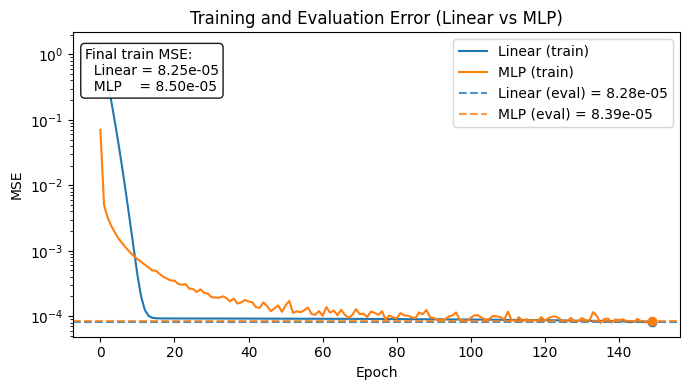

In [39]:
plt.figure(figsize=(7, 4))

# Training curves
plt.semilogy(loss_lin, label="Linear (train)", color="C0")
plt.semilogy(loss_mlp, label="MLP (train)", color="C1")

# Final training values
final_lin = loss_lin[-1]
final_mlp = loss_mlp[-1]

# Mark final points
epoch_last = len(loss_lin) - 1
plt.scatter(epoch_last, final_lin, color="C0", zorder=5)
plt.scatter(epoch_last, final_mlp, color="C1", zorder=5)

# Evaluation errors
plt.axhline(
    test_loss_lin,
    color="C0",
    linestyle="--",
    alpha=0.8,
    label=f"Linear (eval) = {test_loss_lin:.2e}"
)
plt.axhline(
    test_loss_mlp,
    color="C1",
    linestyle="--",
    alpha=0.8,
    label=f"MLP (eval) = {test_loss_mlp:.2e}"
)

# ---- Text box with final train errors ----
textstr = (
    f"Final train MSE:\n"
    f"  Linear = {final_lin:.2e}\n"
    f"  MLP    = {final_mlp:.2e}"
)

plt.text(
    0.02, 0.95, textstr,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training and Evaluation Error (Linear vs MLP)")
plt.legend()
plt.grid(False)   # <-- remove grey grid lines
plt.tight_layout()
plt.show()

C:\Users\amt35\AppData\Local\Temp\ipykernel_48944\736158891.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


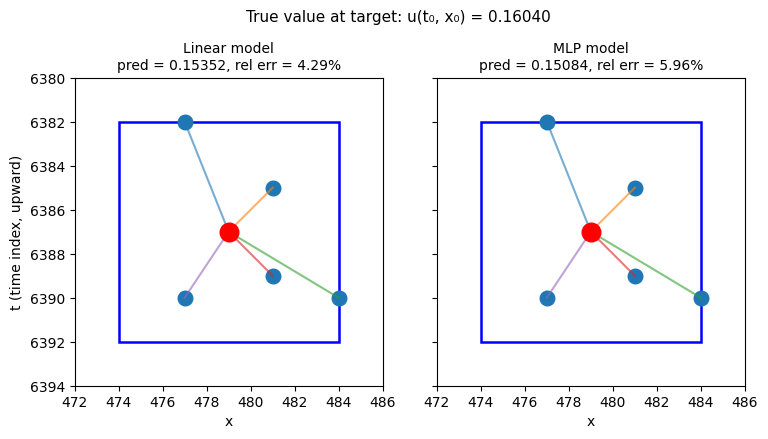

In [54]:
visualize_B_compare_models(data, model_lin, model_mlp, R=5, k=5)